# Notebook 7: Performance Comparison — NW-flex vs BWA-MEM
This notebook compares NW-flex against BWA-MEM, a widely used short-read aligner, on simulated reads from real human STR loci. Where Notebook 6 demonstrated the alignment workflow on a synthetic single locus with random flanks, here we approach real-world conditions: the loci come from a panel of human STR sites in hg38, carrying their genuine flank sequences and repeat motifs. Reads are tiled across haplotypes that vary from the reference in repeat count and (optionally) a single flank base, and we ask under what conditions each method recovers the haplotype's repeat-region length.

**A note on BWA-MEM.** BWA-MEM is a two-stage aligner. It first performs a *global seed search* of the reference, finding maximal exact matches anywhere in the genome. It then performs *local alignment* by Smith-Waterman extension around the most promising seeds, scored with an affine-gap scheme. Soft-clipping arises in this second stage: when extending past a seed costs more than declaring the read end "clipped", BWA-MEM emits an `S` op in the CIGAR. By raising the soft-clip penalty so high that clipping never improves the score, we can effectively disable soft-clipping — letting us see what BWA-MEM does at the boundary when it can't escape into a clip.

## Overview

In this notebook we:

1. **Build the locus simulation** on a panel of real STR loci drawn from hg38 (selected to be pure and locally-isolated). The four stages — reference, haplotype, reads, and mirror — produce reads from an allelic variant of a genomic region that contains a tandem repeat. The last stage generates a "mirror" simulation where all the elements are reverse-complemented.

2. **Use a BWA-MEM-compatible scoring scheme.** NW-flex's defaults module ships with several alternative scoring schemes; for this notebook we select the one whose match, mismatch, gap-open, and gap-extend values match BWA-MEM's defaults, so the two methods see the same scoring landscape on every read.

3. **Set up three alignment configurations**: BWA-MEM at standard parameters; BWA-MEM with the soft-clip penalty raised so high that clipping never improves the score; and NW-flex with the STR-aware EP pattern from Notebook 4. Each configuration runs on both the forward and mirror frames produced by the simulation.

4. **Run two comparisons**, each changing one thing about the simulation:
   - **Length variation only** — haplotype repeat count varies, flanks unchanged.
   - **One SNV in the flank** — same sweep with a single base change two bp into the left flank from the repeat boundary.
   - A third comparison with two adjacent STRs is presented in the next notebook.

5. **Tabulate correctness** for each method as a function of read flank extent and the haplotype's $\Delta$. The verdict combines a length check (does the alignment recover the haplotype's repeat-region length?) with a score check (is the chosen alignment's score equal, lower, or higher than the expected alignment's score?). 

The headline result is structural: when the only difference between haplotype and reference is the repeat count, NW-flex's EP pattern is guaranteed to find the optimum, while a clip-based aligner is at the mercy of its scoring tradeoffs at the boundary. Flank variations expose all aligners to score optimizations that may alter the measured repeat length.

This notebook builds on:

- **Notebook 4**: STR specialization and the phase-preserving EP pattern.
- **Notebook 6**: STR locus simulation and pileup.

**IMPORTANT:** The notebook runs on the included hg38 panel TSV plus `bwa` and `samtools` on `PATH`. If those are missing, the BWA cells skip cleanly with an installation hint.


## Imports and setup



### Imports

Standard scientific-Python imports plus the core NW-flex pieces this notebook builds on. Notebook-specific helpers (panel loading, BWA wrapper, CIGAR decoder) will be added here as the cells that need them are written.

In [116]:
# 🧙 Notebook magic: autoreload modules
%load_ext autoreload
%autoreload 2

# Standard library
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

# Scientific Python
import numpy as np
import pandas as pd

# Notebook display
from IPython.display import display

# NW-flex core
from nwflex.aligners import RefAligner
from nwflex.default import get_default_scoring
from nwflex.ep_patterns import build_EP_STR_phase
from nwflex.repeats import STRLocus

# NW-flex simulation
from nwflex.simulation import (
    align_bwa,
    align_bwa_both_strands,
    align_nwflex,
    alignment_state,
    state_to_glyph,
    build_haplotype,
    build_locus_from_panel,
    build_mirror_frame,
    Read,
    bwa_state_both_strands,
    bwa_truth_cigar,
    combine_states,
    is_arm_correct,
    nwflex_truth_cigar,
    plot_alignment_pileup,
    plot_correctness_heatmap,
    plot_layout_schematic,
    rc_cigar_to_forward,
    rc_to_forward_alignment,
    render_zoom,
    reverse_complement,
    score_alignment,
    tile_reads,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### BWA-MEM and samtools availability

The BWA arms of this notebook shell out to `bwa` and `samtools`, which must be on `PATH`. The cell below checks both; if either is missing, the BWA cells skip cleanly with an installation hint.

In [117]:
required = ("bwa", "samtools")
missing = [t for t in required if shutil.which(t) is None]
if missing:
    print(f"Missing on PATH: {', '.join(missing)}")
    print(f"Install with: conda install -c bioconda {' '.join(missing)}")
    print("BWA-MEM cells will be skipped if these are unavailable.")
else:
    print(f"Found on PATH: {', '.join(required)}")

Found on PATH: bwa, samtools


### Scoring scheme

NW-flex ships several alternative scoring schemes in `nwflex.default`, each a `(score_matrix, gap_open, gap_extend, alphabet_to_undex)` tuple keyed by name. The original NW-flex defaults were chosen for legibility in the teaching notebooks; the additional schemes target compatibility with external aligners.

For this notebook we select the **BWA-MEM-compatible** scheme so that NW-flex and BWA-MEM see matches, mismatches, and gaps under identical costs. With matched scoring, any disagreement between the two methods reflects what each algorithm prefers given the same alignment landscape.

### Same scoring scheme, different alignment scores

While we selected matching alignment parameters, the BWA-MEM results return Smith-Waterman scores that are not strictly comparable to the NW-flex scores.

- **SW score** is BWA-MEM's reported `AS:i:` tag — the Smith-Waterman / local-extension score. BWA-MEM extends from a seed and reports the maximum cumulative score it sees *during* extension, which can sit at an interior cell when the optimal global path dips through an indel.

- **NW score** is the Needleman-Wunsch / global score recomputed from the achieved CIGAR by `score_alignment`, using the same match/mismatch/gap parameters with soft-clips treated as free.

Throughout the rest of this notebook we use the **NW score** whenever we *evaluate* an alignment. It is well-defined for any CIGAR (BWA's output, NW-flex's output, or a constructed truth alignment), and it matches NW-flex's reported `RefAligner` score by construction.

In [118]:
# BWA-MEM-compatible scoring (+1 / -4 / -6 / -1).
score_matrix, gap_open, gap_extend, a2i = get_default_scoring("bwa_mem")

### Input panel


The simulation draws each locus from a panel of human STR sites stored at `data/hg38_motif_sample_K100.tsv`. The panel was built using [Tandem Repeat Finder (TRF)](https://tandem.bu.edu/trf/trf.html) run on hg38 and the results filtered to keep only loci that are *pure* (a clean run of a single canonical motif) and *locally isolated* (no other repeats in the surrounding flank window). Each row gives a genomic location, the motif and tract as found in the reference, and the flanking sequences we use to build the simulation reference. The panel has example loci for mono, di and trinucleotide motifs.

Schema:
| Column | Meaning |
|---|---|
| `pind` | panel index (locus identifier) |
| `chr`, `start_38`, `stop_38`, `strand` | hg38 coordinates of the repeat tract |
| `type` | canonical motif (e.g. `A`, `AC`, `AGG`) |
| `lflank`, `rflank` | left and right flank sequences (500bp) |
| `ms_seq` | repeat tract as it appears in hg38 |
| `ref_score_per_base` | per-base purity score (1.0 = perfect tract) |


> *TODO:* a separate appendix notebook (or script) covering the TRF run, the purity / isolation filters, and the panel-construction steps would make the data reproducible from raw inputs. Out of scope for this notebook; link here when written.

In [119]:
PANEL_PATH = Path("../data/hg38_motif_sample_K100.tsv")
panel = pd.read_csv(PANEL_PATH, sep="\t")

display(panel.head())

print(f"{len(panel):,} loci total")
print()
print("Motif-length breakdown:")
for k, v in panel["type"].str.len().value_counts().sort_index().items():
    print(f"  {k}-bp motif:  {v:>3} loci")

,pind,chr,start_38,stop_38,strand,type,lflank,rflank,ms_seq,ref_score_per_base
0,0,chr1,36351,36364,+,A,CCATCTCTGGGCCCAGAATGACCCACTGGAGACCTTACAGCTCTCC...,CCCAGCCTGGCGGAAAGAATTTAAATTATAAAAACTTAGAAGTATG...,AAAAAAAAAAAAA,1.0
1,1,chr1,51864,51877,+,A,GTGGGGGTTGAGTTTCACTTTATTTAAAGTGAGTCTTAATCCTCCA...,GAAGATTGATCAGAGAGTACCTCCCCTAAGGGTACATGCAGATAAA...,AAAAAAAAAAAAA,1.0
2,2,chr1,71175,71186,+,A,AGTATATTACTTGGATCCATCTATGTCATTTTCCATGGTTAATGTT...,CCTTAACAAATGATTCTGACAAATATCTTCTCTTTCCAGGGAGAAT...,AAAAAAAAAAA,1.0
3,3,chr1,77174,77195,+,A,CTTCATGTCTAAAACACCGAGAGAGGCACTCTTATGCATTGTTGGT...,GGAAAATAACCAAATGACAATTAGTGAGTACTACTTGCAAAACTTG...,AAAAAAAAAAAAAAAAAAAAA,1.0
4,4,chr1,108545,108561,+,A,TGTACCATGCTCCTCCTTAATCATTCTGAGGTTACATCTTAAGTCC...,GAATGGAGAGAATGCTACATGAGAGAAAGGATCTTATCTATCATGT...,AAAAAAAAAAAAAAAA,1.0


6,900 loci total

Motif-length breakdown:
  1-bp motif:  400 loci
  2-bp motif:  1080 loci
  3-bp motif:  5420 loci


## Locus Simulation

We build the locus simulation in four stages:

1. **Reference** — a sequence with known repeat length and boundary, drawn from the panel. We also build an extended copy with three times the motif copies for NW-flex's EP-skip enumeration to consume.
2. **Haplotype** — a sequence sharing the reference's flanks and motif, with a chosen repeat count and an optional flank SNV.
3. **Reads** — fixed-length segments of the haplotype, each spanning the repeat with some flank on each side.
4. **Mirror** — a reverse-complemented copy of everything above so each aligner can be evaluated on both orientations.


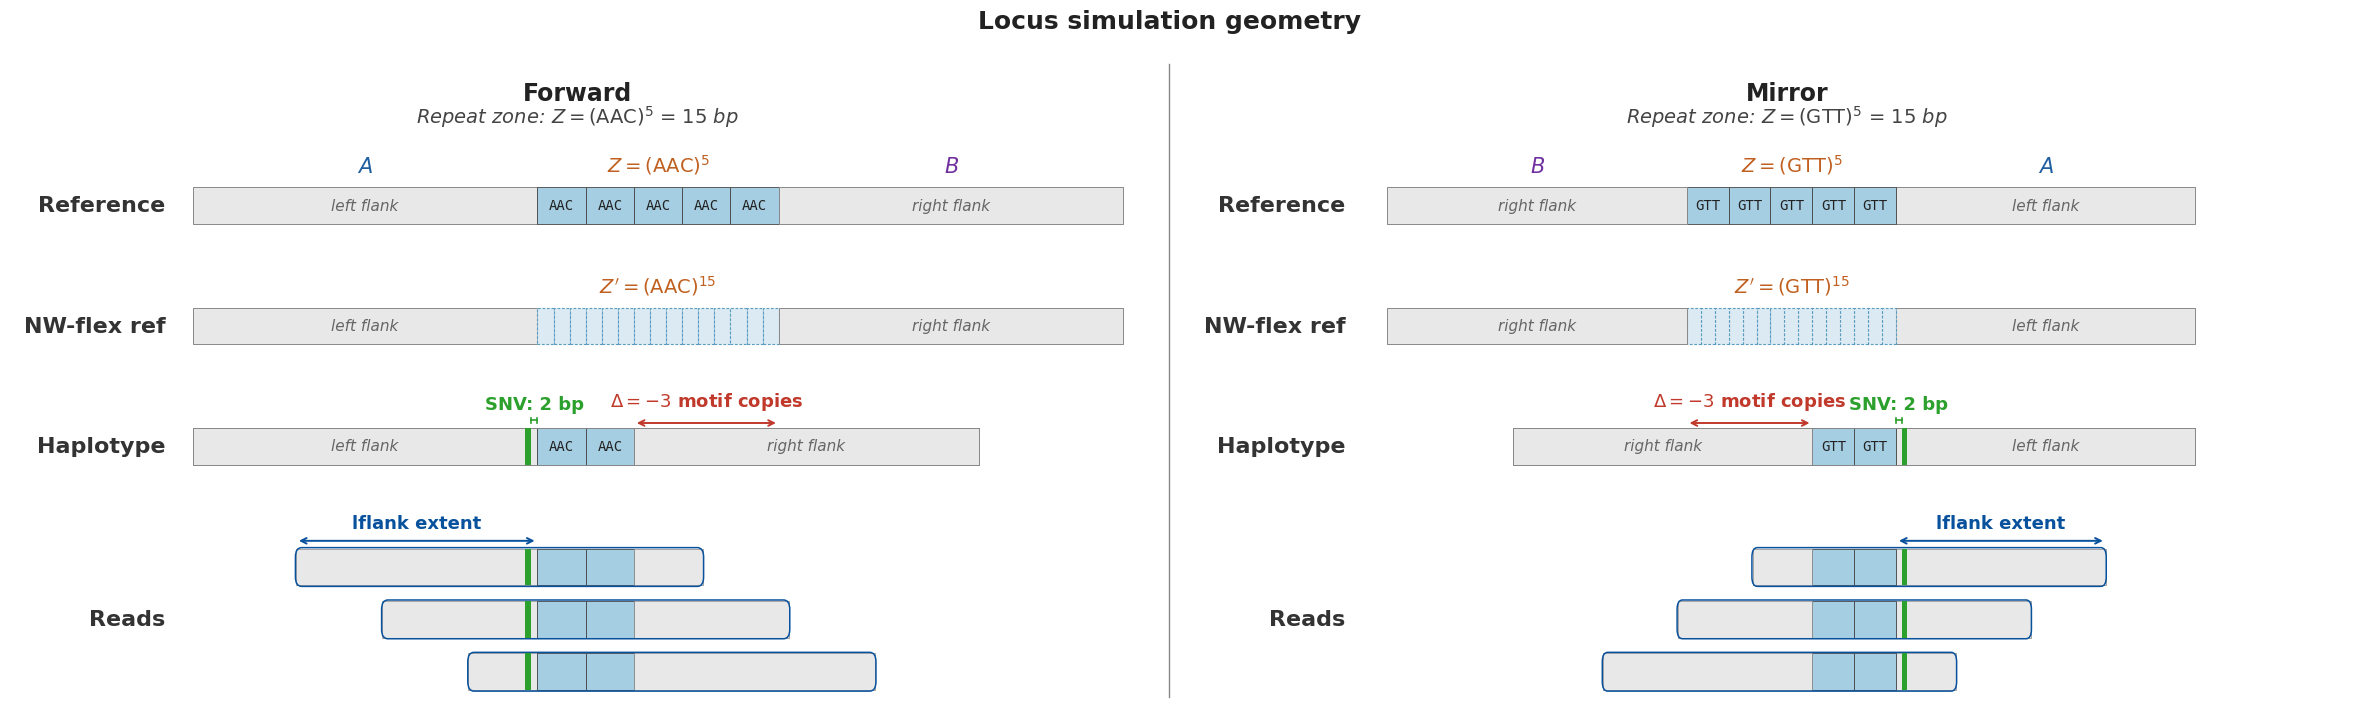

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(24, 7.2))
for ax, mirror in zip(axes, [False, True]):
    plot_layout_schematic(
        motif="AAC",
        ref_n=5,
        delta_example=-3,
        snv={"offset_from_boundary": 2},
        suptitle="Forward" if not mirror else "Mirror",
        flanks_aligned=False,
        show_nwflex=True,
        mirror=mirror,
        ax=ax,
    )
fig.suptitle("Locus simulation geometry",
             fontsize=18, fontweight="bold", color="#222222", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97), w_pad=2)
# Vertical divider between the two panels at the figure midline.
from matplotlib.lines import Line2D
divider = Line2D([0.5, 0.5], [0.04, 0.92], transform=fig.transFigure,
                 color="#888888", linewidth=1.0, linestyle="-")
fig.add_artist(divider)

### Reference

The reference comes from the panel: a real flank pair, a real repeat motif, and a chosen reference repeat count $N$. Together these give the reference sequence $X = A \cdot R^N \cdot B$. Tandem Repeat Finder chooses the motif rotation so the repeat tract begins on a full motif copy, but it does not require the tract to end on one — any trailing partial copy then sits at the start of the right flank, where it would read as an extension of the repeat. For this reason, we use the function `clean_flank_window` to trim the genomic flanks to a clean motif-edge boundary so the flank/repeat boundary is unambiguous. We trim both flanks just in case.

For NW-flex, we also build an **extended reference** with the same flanks and **three times the motif copies**: $X' = A \cdot R^{3N} \cdot B$. The STR-aware EP pattern (Notebook 4) lets NW-flex contract that long repeat run to any allowed haplotype count in a single pass; picking $3N$ keeps the haplotype sweep ($N + \Delta$ for small $|\Delta|$) well inside the allowed range. We re-use the `STRLocus` dataclass with `N = 3*N` to construct it — same flanks, same motif, just more copies.


In [121]:
LOCUS_FLANK_LEN = 200
NWFLEX_FACTOR   = 3   # NW-flex extended reference uses 3N motif copies

# Pick a representative trinucleotide locus from the panel.
row = panel[panel["type"].str.len() == 3].iloc[0]
ref_n = len(row["ms_seq"]) // len(row["type"])

locus = build_locus_from_panel(
    motif=row["type"],
    panel_lflank=row["lflank"],
    panel_rflank=row["rflank"],
    ref_n=ref_n,
    flank_len=LOCUS_FLANK_LEN,
)

# Extended NW-flex reference: same flanks, same motif, NWFLEX_FACTOR * N copies.
nwflex_locus = STRLocus(
    A=locus.A, R=locus.R, N=NWFLEX_FACTOR * locus.N, B=locus.B,
)

print(f"pind={row['pind']}  motif={locus.R!r}  ref N={locus.N}")
print()
print("Locus reference (X = A · R^N · B):")
print(f"  X length: {locus.n}  ({len(locus.A)} flank + {locus.k * locus.N} repeat + {len(locus.B)} flank)")
print(f"  flank lengths: panel {len(row['lflank'])}/{len(row['rflank'])} bp → locus {len(locus.A)}/{len(locus.B)} bp")
print(f"  z_start={locus.s}  z_end={locus.e}")
print(f"  A[-10:] = {locus.A[-10:]}   (last base must not be {locus.R[-1]!r})")
print(f"  B[:10]  = {locus.B[:10]}   (first base must not be {locus.R[0]!r})")
print()
print(f"NW-flex extended reference (X' = A · R^{NWFLEX_FACTOR}N · B,  N' = {nwflex_locus.N}):")
print(f"  X' length: {nwflex_locus.n}  ({len(nwflex_locus.A)} flank + {nwflex_locus.k * nwflex_locus.N} repeat + {len(nwflex_locus.B)} flank)")
print(f"  z_start={nwflex_locus.s}  z_end={nwflex_locus.e}")


pind=1480  motif='AAC'  ref N=5

Locus reference (X = A · R^N · B):
  X length: 415  (200 flank + 15 repeat + 200 flank)
  flank lengths: panel 500/500 bp → locus 200/200 bp
  z_start=200  z_end=215
  A[-10:] = GCTGCTTATA   (last base must not be 'C')
  B[:10]  = CATTGACAGG   (first base must not be 'A')

NW-flex extended reference (X' = A · R^3N · B,  N' = 15):
  X' length: 445  (200 flank + 45 repeat + 200 flank)
  z_start=200  z_end=245


### Haplotype

The haplotype is the sequence we sample reads from. It shares the reference's flanks and motif but can differ from the reference in two ways: an optional difference in the number of repeat copies, and an optional single-nucleotide variant (SNV) at a chosen position in one of the flanks.

In [122]:
DELTA = 1  # haplotype has one extra repeat copy vs the locus

hap = build_haplotype(locus, delta=DELTA)
rflank_len = len(hap.sequence) - hap.flank_len - hap.body_len

print("An example haplotype:")
print(f"locus N={locus.N}  →  haplotype N={locus.N + DELTA}")
print(f"  hap length: {len(hap.sequence)}  ({hap.flank_len} flank + {hap.body_len} repeat + {rflank_len} flank)")

An example haplotype:
locus N=5  →  haplotype N=6
  hap length: 418  (200 flank + 18 repeat + 200 flank)


### Reads

Each read is a fixed-length contiguous segment of the haplotype. We generate one read at every starting position whose segment covers at least $K$ bases of each flank: this guarantees the read spans the repeat and gives the alignment flank context on both sides. The number of flank bases a read covers on each side is its *flank extent*.

In [123]:
READ_LEN = 150
K_MIN_FLANK = 1

reads = tile_reads(hap, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
lflank_extents = sorted({r.lflank_extent for r in reads})
rflank_extents = sorted({r.rflank_extent for r in reads})

print(f"Tiled {len(reads)} reads (read_len={READ_LEN}, k_min_flank={K_MIN_FLANK})")
print(f"  lflank_extent: {lflank_extents[0]}..{lflank_extents[-1]}")
print(f"  rflank_extent: {rflank_extents[0]}..{rflank_extents[-1]}")

Tiled 131 reads (read_len=150, k_min_flank=1)
  lflank_extent: 1..131
  rflank_extent: 1..131


### Mirror

For symmetric scoring (matches, mismatches, and gaps cost the same in either direction), we would expect aligning a read against a reference to give an equivalent answer to aligning the reverse-complement of the read against the reverse-complement of the reference. In practice this symmetry doesn't always hold — for two reasons:

- **Tie-breaking.** When several alignments share the optimal score, the one returned is determined by the implementation's tie-break rule, which typically depends on the order in which DP cells are scanned. Reversing both read and reference reverses that scan order, so the rc arm can return a different element of the same co-optimum set.
- **Directional heuristics.** BWA-MEM's two-stage pipeline (seed search → Smith-Waterman extension) is direction-dependent: the seeds it finds, and the boundary at which extension gives up and turns into soft-clip, can differ between a read and its reverse complement.

The mirror frame is built into the simulation by design, so the comparison is fair to every aligner. Each one sees both the forward frame `(reference, reads, repeat-zone)` and the mirror frame `(rc-reference, rc-reads, mirrored-zone)`, and the analysis combines both.

The cell below mirrors both the locus reference and the NW-flex extended reference in a single call, so every aligner has its `(reads, reference, zone)` pair on both strands ready before any alignment runs.


In [124]:
(rc_locus_X, rc_reads, rc_zone,
 rc_nwflex_X,           rc_nwflex_zone) = build_mirror_frame(
    reference=locus.X,
    reads=reads,
    zone=(locus.s, locus.e),
    extra_reference=nwflex_locus.X,
    extra_zone=(nwflex_locus.s, nwflex_locus.e),
)

print(f"forward locus  zone = ({locus.s}, {locus.e})")
print(f"mirror  locus  zone = {rc_zone}")
print(f"forward 3N     zone = ({nwflex_locus.s}, {nwflex_locus.e})")
print(f"mirror  3N     zone = {rc_nwflex_zone}")
print()
print(f"forward read[0] lflank/rflank extent = "
      f"{reads[0].lflank_extent}/{reads[0].rflank_extent}")
print(f"mirror  read[0] lflank/rflank extent = "
      f"{rc_reads[0].lflank_extent}/{rc_reads[0].rflank_extent}")


forward locus  zone = (200, 215)
mirror  locus  zone = (200, 215)
forward 3N     zone = (200, 245)
mirror  3N     zone = (200, 245)

forward read[0] lflank/rflank extent = 131/1
mirror  read[0] lflank/rflank extent = 1/131


## Three alignment configurations

We run three alignment configurations per read. Each configuration produces **two alignments**: one for the forward (read, reference) pair from the simulation and one for the mirror (rc-read, rc-reference) pair. Each read therefore yields six alignments across the three configurations:

1. BWA-MEM at standard parameters — forward, mirror.
2. BWA-MEM with soft-clipping suppressed — forward, mirror.
3. NW-flex — forward, mirror.

The aligner harnesses are orientation-agnostic: each takes a list of reads and a reference and aligns each read against that reference. The forward/mirror distinction lives in the simulation, not in the harness call.

### BWA-MEM configurations

BWA-MEM's pipeline is two stages: a global seed search, then Smith-Waterman extension from each viable seed. We index the locus reference (and the mirror reference) once and run `bwa mem` on the corresponding read list.

The two BWA configurations differ only in the soft-clip penalty. **Standard** uses BWA-MEM's defaults, which allow soft-clipping when it improves the local-extension score. **No-clip** raises the soft-clip penalty (`-L 500`) so high that clipping never improves the score, effectively disabling it. This isolates the soft-clip mechanism: a regime where both BWA arms fail is a structural failure, not a clipping artifact.


In [125]:
# Three reads spanning the boundary range.
illustrative_idx = [0, len(reads) // 2, len(reads) - 1]
illustrative_reads        = [reads[i]    for i in illustrative_idx]
illustrative_mirror_reads = [rc_reads[i] for i in illustrative_idx]

# Each BWA configuration produces a (forward, mirror) pair of alignments:
# forward reads aligned to the locus reference, mirror reads aligned to
# the mirror reference.  The harness has no orientation knob — the two
# runs differ only in which reads + reference are passed in.
res_std    = align_bwa(locus.X,    illustrative_reads,        no_clip=False)
res_std_rc = align_bwa(rc_locus_X, illustrative_mirror_reads, no_clip=False)
res_noclip = align_bwa(locus.X,    illustrative_reads,        no_clip=True)
res_nc_rc  = align_bwa(rc_locus_X, illustrative_mirror_reads, no_clip=True)

# BWA-MEM reports the SW (Smith-Waterman / local-extension) score in
# its AS:i: tag.  We rescore each achieved CIGAR using `score_alignment`
# to obtain its NW (Needleman-Wunsch / global) score under the same
# affine-gap parameters with soft-clips treated as free.
sc_kw = dict(score_matrix=score_matrix, gap_open=gap_open,
             gap_extend=gap_extend, alphabet_to_index=a2i)

def _nw(read, ref, hit):
    return int(score_alignment(read.sequence, ref, hit.pos, hit.cigar, **sc_kw))

# Mirror CIGARs walk the rc-reference left-to-right; for side-by-side
# comparison we display them in forward-locus coordinates, via
# `rc_cigar_to_forward`.
ref_length = len(locus.X)

# Long-format table: one row per (read, mode, orientation).
table_rows = []
for k, ix in enumerate(illustrative_idx):
    r_fwd = illustrative_reads[k]
    r_rc  = illustrative_mirror_reads[k]
    for mode, h_fwd, h_rc in (
        ("std",     res_std[k],    res_std_rc[k]),
        ("no-clip", res_noclip[k], res_nc_rc[k]),
    ):
        table_rows.append({
            "read": ix,
            "lflank": r_fwd.lflank_extent, "rflank": r_fwd.rflank_extent,
            "mode": mode, "orient": "fwd",
            "cigar": h_fwd.cigar,
            "SW score": int(h_fwd.score),
            "NW score": _nw(r_fwd, locus.X, h_fwd),
        })
        table_rows.append({
            "read": ix,
            "lflank": r_fwd.lflank_extent, "rflank": r_fwd.rflank_extent,
            "mode": mode, "orient": "mirror",
            "cigar": rc_cigar_to_forward(h_rc.pos, h_rc.cigar, ref_length),
            "SW score": int(h_rc.score),
            "NW score": _nw(r_rc, rc_locus_X, h_rc),
        })

print("BWA-MEM on three illustrative reads "
      "— std vs no-clip, forward vs mirror "
      "(mirror CIGARs shown in forward-locus coordinates):")
pd.DataFrame(table_rows)


BWA-MEM on three illustrative reads — std vs no-clip, forward vs mirror (mirror CIGARs shown in forward-locus coordinates):


,read,lflank,rflank,mode,orient,cigar,SW score,NW score
0,0,131,1,std,fwd,146M4S,146,146
1,0,131,1,std,mirror,146M4S,146,146
2,0,131,1,no-clip,fwd,131M3I16M,146,138
3,0,131,1,no-clip,mirror,146M3I1M,146,138
4,65,66,66,std,fwd,66M3I81M,138,138
5,65,66,66,std,mirror,81M3I66M,138,138
6,65,66,66,no-clip,fwd,66M3I81M,138,138
7,65,66,66,no-clip,mirror,81M3I66M,138,138
8,130,1,131,std,fwd,4S146M,146,146
9,130,1,131,std,mirror,4S146M,146,146


For the centered read (idx 65) the two scores agree. For the boundary reads (idx 0 and 130) under no-clip, BWA still emits the indel-bearing alignment but its reported SW score reflects the higher pre-indel maximum — so **SW = 146 while NW = 138**.


### NW-flex configuration

The third configuration uses NW-flex for an STR locus, with the extra-spacious $3N$-copy extended reference to give the EP pattern room to contract to the haplotype's repeat count.

The harness `align_nwflex` mirrors `align_bwa`: it takes a reference, a list of reads, and the scoring scheme, and returns one alignment per read in input order. As with BWA, the harness has no orientation knob — we run it twice, once on the forward (read, reference) pair and once on the mirror pair, both built by the simulation setup above.


In [126]:
# EP patterns for the forward and mirror NW-flex references.  Each is
# tied to its reference's repeat-zone coordinates, so the forward and
# mirror frames need their own EP construction.  We define them here
# so downstream sweep cells can reuse them.
EP_fwd = build_EP_STR_phase(
    nwflex_locus.n, nwflex_locus.s, nwflex_locus.e, nwflex_locus.k,
)
EP_rc  = build_EP_STR_phase(
    nwflex_locus.n, *rc_nwflex_zone, nwflex_locus.k,
)

# Mirror reads for the three illustrative indices (paired with the
# forward reads by list index, since build_mirror_frame preserves order
# and var_start).
illustrative_mirror_reads = [rc_reads[i] for i in illustrative_idx]

scoring_kw = dict(
    score_matrix=score_matrix, gap_open=gap_open,
    gap_extend=gap_extend, alphabet_to_index=a2i,
)
res_nwflex    = align_nwflex(nwflex_locus.X, illustrative_reads,
                              extra_predecessors=EP_fwd, **scoring_kw)
res_nwflex_rc = align_nwflex(rc_nwflex_X,    illustrative_mirror_reads,
                              extra_predecessors=EP_rc,  **scoring_kw)

# Mirror CIGARs are displayed in forward-locus coordinates.
nwflex_ref_length = len(nwflex_locus.X)

# Long-format table: one row per (read, orientation).  NW-flex has a
# single mode, so the comparison axis here is forward vs mirror only.
table_rows = []
for k, ix in enumerate(illustrative_idx):
    r_fwd = illustrative_reads[k]
    fwd_hit = res_nwflex[k]
    rc_hit  = res_nwflex_rc[k]
    table_rows.append({
        "read": ix,
        "lflank": r_fwd.lflank_extent, "rflank": r_fwd.rflank_extent,
        "orient": "fwd",
        "cigar": fwd_hit.cigar,
        "NW score": int(fwd_hit.score),
    })
    table_rows.append({
        "read": ix,
        "lflank": r_fwd.lflank_extent, "rflank": r_fwd.rflank_extent,
        "orient": "mirror",
        "cigar": rc_cigar_to_forward(rc_hit.pos, rc_hit.cigar,
                                     nwflex_ref_length),
        "NW score": int(rc_hit.score),
    })

print("NW-flex on three illustrative reads "
      "(3N reference, STR-aware EP; "
      "mirror CIGARs shown in forward-locus coordinates):")
pd.DataFrame(table_rows)


NW-flex on three illustrative reads (3N reference, STR-aware EP; mirror CIGARs shown in forward-locus coordinates):


,read,lflank,rflank,orient,cigar,NW score
0,0,131,1,fwd,131M27N19M,150
1,0,131,1,mirror,149M27N1M,150
2,65,66,66,fwd,66M27N84M,150
3,65,66,66,mirror,84M27N66M,150
4,130,1,131,fwd,1M27N149M,150
5,130,1,131,mirror,19M27N131M,150


### Correctness rule

The table below classifies each (read, configuration) along two axes:

**Length (✓ / ✗).** Did the alignment recover the haplotype's repeat-region length? The check fails when either the alignment doesn't span the repeat (typically a soft-clip eating one of the flanks) or it spans the repeat but decodes the wrong number of motif copies inside. Both conditions must hold for ✓.

**Score vs truth (`<` / `=` / `>`).** Compare the chosen alignment's score to the score of the natural *truth* alignment under the same scoring scheme. A length-correct alignment necessarily ties the truth — the truth *is* the correct alignment — so this column only carries information when length has failed:

- `<` — heuristic miss: the aligner left score on the table.
- `=` — truth was co-optimal; tie-break landed on a different element of the optimum set.
- `>` — the score landscape itself prefers a wrong alignment.


In [ ]:
# Per-(read, configuration, orient) verdict glyphs:
#   length: ✓ if the alignment recovers the haplotype's repeat length, ✗ otherwise.
#   score:  <, =, > comparing the chosen NW score to the truth NW score.
# Glyphs come from alignment_state + state_to_glyph in the simulation
# package; this cell just composes them across methods and orientations.
sc_kw = dict(score_matrix=score_matrix, gap_open=gap_open,
             gap_extend=gap_extend, alphabet_to_index=a2i)
truth_z_bp = hap.body_len

def classify(read, ref, zone, hit, truth_nw, *, convention):
    nw = score_alignment(read.sequence, ref, hit.pos, hit.cigar, **sc_kw)
    state = alignment_state(
        hit.cigar, hit.pos, nw, truth_nw, *zone, truth_z_bp,
        convention=convention,
    )
    return state_to_glyph(state)

# Per-read truth NW scores under each convention (orientation-invariant
# under symmetric scoring).
truth_bwa = [score_alignment(r.sequence, locus.X,
                             *bwa_truth_cigar(r, hap, locus), **sc_kw)
             for r in illustrative_reads]
truth_nwf = [score_alignment(r.sequence, nwflex_locus.X,
                             *nwflex_truth_cigar(r, hap, nwflex_locus), **sc_kw)
             for r in illustrative_reads]

read_labels = [f"r{ix:03d} (lf={r.lflank_extent}, rf={r.rflank_extent})"
               for ix, r in zip(illustrative_idx, illustrative_reads)]

# One lane per (method, orient) carrying everything classify() needs.
# Order matters: it becomes the row order in the final table.
lanes = [
    dict(method="std",     orient="fwd",    reads=illustrative_reads,        ref=locus.X,        zone=(locus.s, locus.e),                hits=res_std,       convention="bwa",    truth=truth_bwa),
    dict(method="std",     orient="mirror", reads=illustrative_mirror_reads, ref=rc_locus_X,     zone=rc_zone,                           hits=res_std_rc,    convention="bwa",    truth=truth_bwa),
    dict(method="no-clip", orient="fwd",    reads=illustrative_reads,        ref=locus.X,        zone=(locus.s, locus.e),                hits=res_noclip,    convention="bwa",    truth=truth_bwa),
    dict(method="no-clip", orient="mirror", reads=illustrative_mirror_reads, ref=rc_locus_X,     zone=rc_zone,                           hits=res_nc_rc,     convention="bwa",    truth=truth_bwa),
    dict(method="NW-flex", orient="fwd",    reads=illustrative_reads,        ref=nwflex_locus.X, zone=(nwflex_locus.s, nwflex_locus.e),  hits=res_nwflex,    convention="nwflex", truth=truth_nwf),
    dict(method="NW-flex", orient="mirror", reads=illustrative_mirror_reads, ref=rc_nwflex_X,    zone=rc_nwflex_zone,                    hits=res_nwflex_rc, convention="nwflex", truth=truth_nwf),
]

# Build tidy (long-format) records, then pivot to wide.
records = [
    {"method": lane["method"], "orient": lane["orient"],
     "read": read_labels[k],
     "verdict": classify(lane["reads"][k], lane["ref"], lane["zone"],
                         lane["hits"][k], lane["truth"][k],
                         convention=lane["convention"])}
    for lane in lanes
    for k in range(len(illustrative_idx))
]

row_index = pd.MultiIndex.from_tuples(
    [(lane["method"], lane["orient"]) for lane in lanes],
    names=["method", "orient"],
)
verdict_df = (
    pd.DataFrame(records)
      .pivot(index=["method", "orient"], columns="read", values="verdict")
      .reindex(index=row_index, columns=read_labels)
)

print(f"Truth z_bp = (N + Δ) · |R| = {truth_z_bp}    "
      "(length ✓/✗  +  score <, =, > vs truth)")
verdict_df


## First comparison — length variation only

We run the simulation above with the haplotype flanks left untouched and the repeat count varying over $N + \Delta$ for a small range of $\Delta$. We tabulate correctness for each method as a function of flank extent and $\Delta$ and present the result as a heatmap with one panel per method.

**Expected result.** NW-flex is uniformly correct as long as the read has any flank extent. BWA-MEM at standard parameters fails along the boundary even though the haplotype differs from the reference only in the repeat count. The no-clip arm recovers some of these cases but not all.

In [129]:
LFLANK_EXTENTS = list(range(1, 11))     # y axis (high → top)
DELTAS         = list(range(-5, 6))     # x axis

# combine policy for the *summary* state column (P/T/M/D priority).
# The plot helper renders fwd_state and rc_state independently as the
# cell's box (fwd) and circle (rc), so the visualization is unaffected.
COMBINE = "best"

bwa_zone   = (locus.s, locus.e)
nw_zone    = (nwflex_locus.s, nwflex_locus.e)
ref_length = len(locus.X)
sc_kw = dict(score_matrix=score_matrix, gap_open=gap_open,
             gap_extend=gap_extend, alphabet_to_index=a2i)

def _mirror_reads(forward_reads):
    """Build mirror Read objects (rc-sequence, swapped extents) for a
    forward read list.  Equivalent to taking the per-haplotype slice
    out of a build_mirror_frame call, without rebuilding the reference.
    """
    return [
        Read(sequence=reverse_complement(r.sequence),
             var_start=r.var_start,
             lflank_extent=r.rflank_extent,
             rflank_extent=r.lflank_extent)
        for r in forward_reads
    ]

rows = []
for delta in DELTAS:
    h     = build_haplotype(locus, delta=delta)
    rs    = tile_reads(h, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
    truth = h.body_len

    # Geometry: with fixed read_len, each lflank_extent picks one read.
    by_l       = {r.lflank_extent: r for r in rs}
    cell_reads = [by_l.get(L) for L in LFLANK_EXTENTS]
    feasible   = [r for r in cell_reads if r is not None]

    # Batch the BWA / NW-flex calls per delta.  NW-flex is run on
    # both strands via align_nwflex (forward + mirror frame) for
    # symmetry with the BWA arms.
    bwa_std = align_bwa_both_strands(locus.X, feasible, no_clip=False)
    bwa_nc  = align_bwa_both_strands(locus.X, feasible, no_clip=True)
    nwf_fwd = align_nwflex(nwflex_locus.X, feasible,
                           extra_predecessors=EP_fwd, **sc_kw)
    nwf_rc  = align_nwflex(rc_nwflex_X, _mirror_reads(feasible),
                           extra_predecessors=EP_rc, **sc_kw)

    fi = 0
    for L, r in zip(LFLANK_EXTENTS, cell_reads):
        if r is None:
            for arm in ("std", "no-clip", "NW-flex"):
                rows.append({"delta": delta, "lflank": L, "arm": arm,
                             "state": np.nan,
                             "fwd_state": np.nan, "rc_state": np.nan})
            continue

        # NW (truth) scores for this read.  DNA scoring is symmetric, so
        # the same truth_nw_nw applies to both NW-flex strands.
        truth_nw_bwa = score_alignment(
            r.sequence, locus.X, *bwa_truth_cigar(r, h, locus), **sc_kw,
        )
        truth_nw_nw = score_alignment(
            r.sequence, nwflex_locus.X,
            *nwflex_truth_cigar(r, h, nwflex_locus), **sc_kw,
        )

        for arm, both in (("std", bwa_std[fi]), ("no-clip", bwa_nc[fi])):
            res = bwa_state_both_strands(
                both, *bwa_zone, truth, ref_length, truth_nw_bwa,
                r.sequence, locus.X, **sc_kw, combine=COMBINE,
            )
            rows.append({"delta": delta, "lflank": L, "arm": arm,
                         "state": res.state,
                         "fwd_state": res.fwd_state, "rc_state": res.rc_state})

        # NW-flex: classify each strand against its frame, then combine.
        hit_fwd = nwf_fwd[fi]
        hit_rc  = nwf_rc[fi]
        nw_fwd_state = alignment_state(
            hit_fwd.cigar, hit_fwd.pos, float(hit_fwd.score),
            truth_nw_nw, *nw_zone, truth, convention="nwflex",
        )
        nw_rc_state = alignment_state(
            hit_rc.cigar, hit_rc.pos, float(hit_rc.score),
            truth_nw_nw, *rc_nwflex_zone, truth, convention="nwflex",
        )
        nw_state = combine_states(nw_fwd_state, nw_rc_state, COMBINE)
        rows.append({"delta": delta, "lflank": L, "arm": "NW-flex",
                     "state": nw_state,
                     "fwd_state": nw_fwd_state, "rc_state": nw_rc_state})
        fi += 1

val1_df = pd.DataFrame(rows)
print(f"Sweep: {len(LFLANK_EXTENTS)} lflanks × {len(DELTAS)} Δs × 3 arms "
      f"= {len(val1_df)} verdicts  (combine={COMBINE!r})")
val1_df.groupby("arm")["state"].value_counts().unstack(fill_value=0)


Sweep: 10 lflanks × 11 Δs × 3 arms = 330 verdicts  (combine='best')


state,D,P
arm,,
NW-flex,0,110
no-clip,18,92
std,82,28


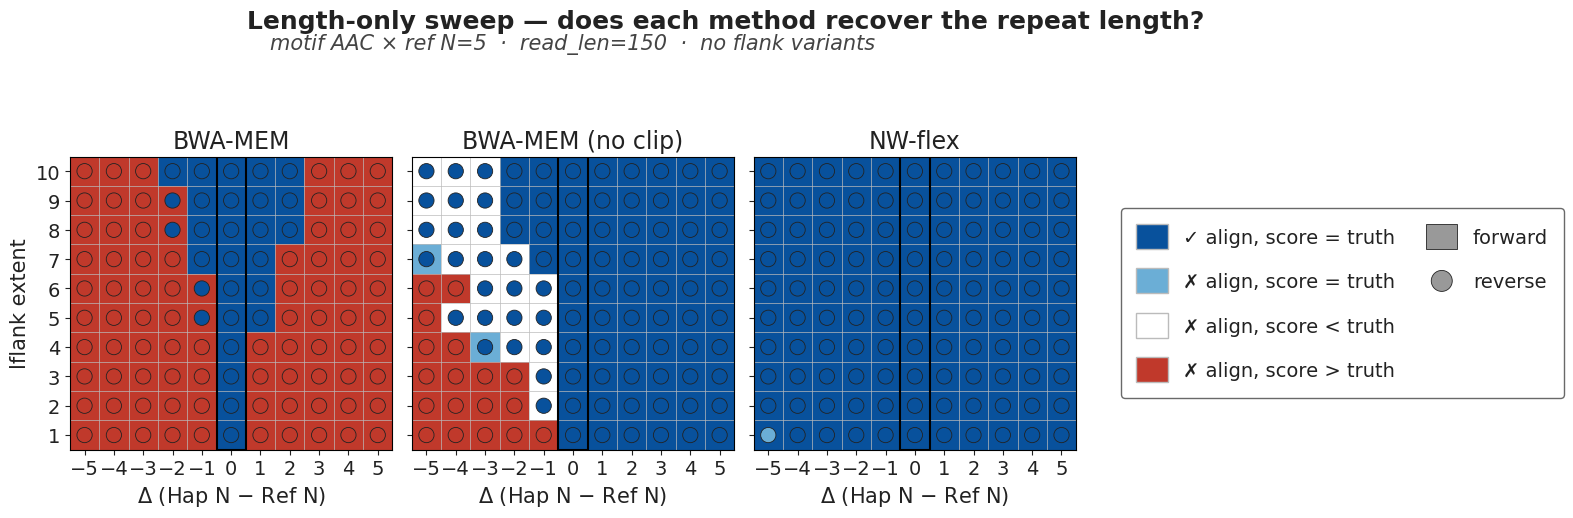

In [130]:
ARM_TITLES = {
    "std":     "BWA-MEM",
    "no-clip": "BWA-MEM (no clip)",
    "NW-flex": "NW-flex",
}

plot_correctness_heatmap(
    val1_df,
    deltas=DELTAS,
    lflanks=LFLANK_EXTENTS,
    arm_titles=ARM_TITLES,
    suptitle="Length-only sweep — does each method recover the repeat length?",
    subtitle=(
        f"motif {locus.R} × ref N={locus.N}  ·  read_len={READ_LEN}  ·  "
        "no flank variants"
    ),
);

## Second comparison — a single SNV in the flank

We repeat the first comparison with one change: the haplotype carries a single SNV at a fixed position. We choose for our example a single base change in the left flank, three bases before the start of the repeat. The locus, the read tiling, and the alignment configurations are unchanged.

**Expected result.** The same heatmap now reads differently. NW-flex remains correct in the regime where it has flank overhang, but not always — sometimes the local sequence and variant have a higher-value alignment. The no-clip arm — the one that recovered the easy cases above — now fails on the reads that cross the SNV.

In [131]:
# SNV: 2 bp into the left flank from the repeat boundary; alt = any non-ref base.
SNV_LFLANK_OFFSET = 2
SNV_POS = locus.s - SNV_LFLANK_OFFSET
SNV_REF = locus.X[SNV_POS]
SNV_ALT = next(b for b in "ACGT" if b != SNV_REF)
print(f"SNV at hap pos {SNV_POS}  ({SNV_LFLANK_OFFSET} bp into lflank from "
      f"boundary at {locus.s}):  {SNV_REF} → {SNV_ALT}")

bwa_zone   = (locus.s, locus.e)
nw_zone    = (nwflex_locus.s, nwflex_locus.e)
ref_length = len(locus.X)
sc_kw = dict(score_matrix=score_matrix, gap_open=gap_open,
             gap_extend=gap_extend, alphabet_to_index=a2i)

rows = []
for delta in DELTAS:
    h     = build_haplotype(locus, delta=delta, snv=(SNV_POS, SNV_ALT))
    rs    = tile_reads(h, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
    truth = h.body_len

    by_l       = {r.lflank_extent: r for r in rs}
    cell_reads = [by_l.get(L) for L in LFLANK_EXTENTS]
    feasible   = [r for r in cell_reads if r is not None]

    bwa_std = align_bwa_both_strands(locus.X, feasible, no_clip=False)
    bwa_nc  = align_bwa_both_strands(locus.X, feasible, no_clip=True)
    nwf_fwd = align_nwflex(nwflex_locus.X, feasible,
                           extra_predecessors=EP_fwd, **sc_kw)
    nwf_rc  = align_nwflex(rc_nwflex_X, _mirror_reads(feasible),
                           extra_predecessors=EP_rc, **sc_kw)

    fi = 0
    for L, r in zip(LFLANK_EXTENTS, cell_reads):
        if r is None:
            for arm in ("std", "no-clip", "NW-flex"):
                rows.append({"delta": delta, "lflank": L, "arm": arm,
                             "state": np.nan,
                             "fwd_state": np.nan, "rc_state": np.nan})
            continue

        truth_nw_bwa = score_alignment(
            r.sequence, locus.X, *bwa_truth_cigar(r, h, locus), **sc_kw,
        )
        truth_nw_nw = score_alignment(
            r.sequence, nwflex_locus.X,
            *nwflex_truth_cigar(r, h, nwflex_locus), **sc_kw,
        )

        for arm, both in (("std", bwa_std[fi]), ("no-clip", bwa_nc[fi])):
            res = bwa_state_both_strands(
                both, *bwa_zone, truth, ref_length, truth_nw_bwa,
                r.sequence, locus.X, **sc_kw, combine=COMBINE,
            )
            rows.append({"delta": delta, "lflank": L, "arm": arm,
                         "state": res.state,
                         "fwd_state": res.fwd_state, "rc_state": res.rc_state})

        # NW-flex: classify each strand against its frame, then combine.
        hit_fwd = nwf_fwd[fi]
        hit_rc  = nwf_rc[fi]
        nw_fwd_state = alignment_state(
            hit_fwd.cigar, hit_fwd.pos, float(hit_fwd.score),
            truth_nw_nw, *nw_zone, truth, convention="nwflex",
        )
        nw_rc_state = alignment_state(
            hit_rc.cigar, hit_rc.pos, float(hit_rc.score),
            truth_nw_nw, *rc_nwflex_zone, truth, convention="nwflex",
        )
        nw_state = combine_states(nw_fwd_state, nw_rc_state, COMBINE)
        rows.append({"delta": delta, "lflank": L, "arm": "NW-flex",
                     "state": nw_state,
                     "fwd_state": nw_fwd_state, "rc_state": nw_rc_state})
        fi += 1

val2_df = pd.DataFrame(rows)
print(f"Sweep: {len(LFLANK_EXTENTS)} lflanks × {len(DELTAS)} Δs × 3 arms "
      f"= {len(val2_df)} verdicts  (combine={COMBINE!r})")
val2_df.groupby("arm")["state"].value_counts().unstack(fill_value=0)


SNV at hap pos 198  (2 bp into lflank from boundary at 200):  T → A
Sweep: 10 lflanks × 11 Δs × 3 arms = 330 verdicts  (combine='best')


state,D,P,T
arm,,,
NW-flex,3,77,30
no-clip,52,58,0
std,98,12,0


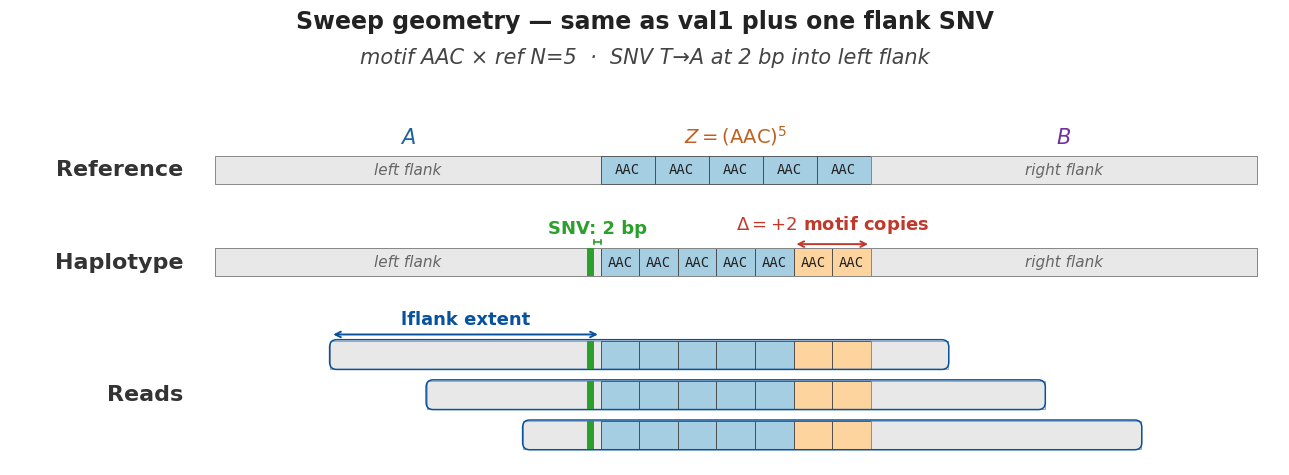

In [132]:
plot_layout_schematic(
    motif=locus.R,
    ref_n=locus.N,
    delta_example=2,
    snv={"offset_from_boundary": SNV_LFLANK_OFFSET},
    suptitle="Sweep geometry — same as val1 plus one flank SNV",
    subtitle=(
        f"motif {locus.R} × ref N={locus.N}  ·  "
        f"SNV {SNV_REF}→{SNV_ALT} at {SNV_LFLANK_OFFSET} bp into left flank"
    ),
);

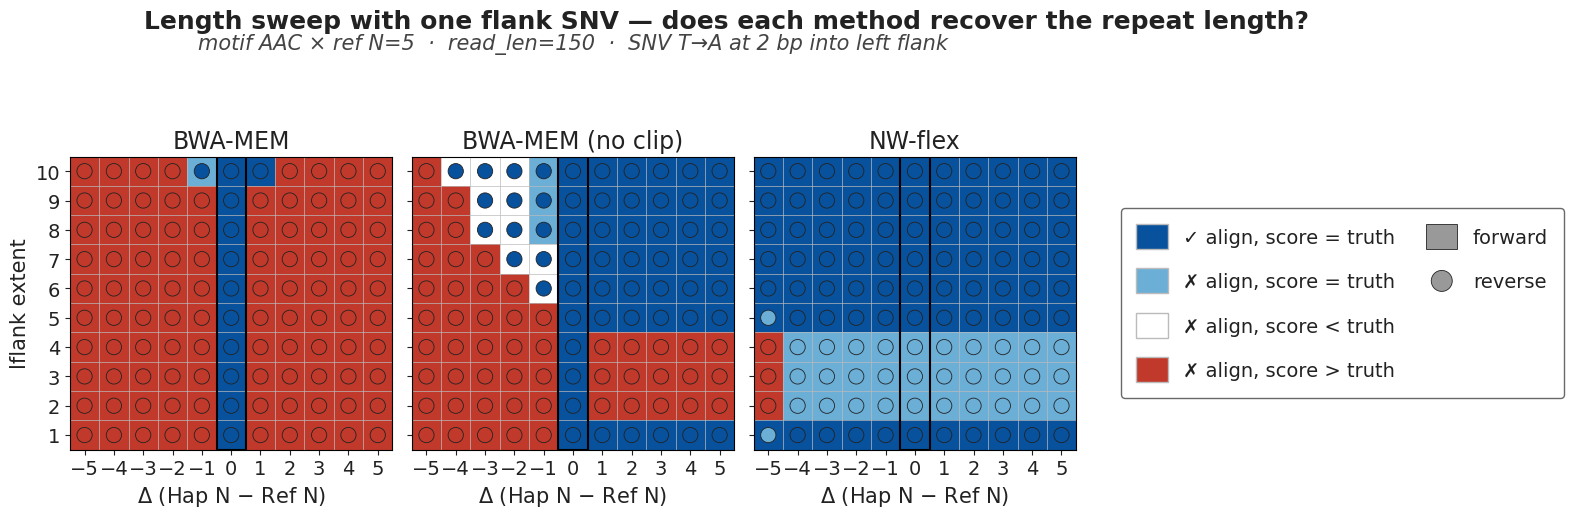

In [133]:
plot_correctness_heatmap(
    val2_df,
    deltas=DELTAS,
    lflanks=LFLANK_EXTENTS,
    arm_titles=ARM_TITLES,
    suptitle="Length sweep with one flank SNV — does each method recover the repeat length?",
    subtitle=(
        f"motif {locus.R} × ref N={locus.N}  ·  read_len={READ_LEN}  ·  "
        f"SNV {SNV_REF}→{SNV_ALT} at {SNV_LFLANK_OFFSET} bp into left flank"
    ),
);

### Are these failures real, or tie-break artifacts?

The heatmap shows NW-flex failing across a band of `(Δ, lflank)` cells. Before concluding that NW-flex is "wrong" on those cells, we should ask: is each failure a *real* one, or a tie-break artifact?

This connects directly to the **inequivalence-of-orientations** demo earlier in the notebook. There we saw that when an aligner faces multiple equally-optimal alignments, the one it returns is determined by deterministic tie-break rather than by which alignment recovers the truth. For BWA we worked around this by running both orientations (the RC trick) — running the alignment in mirror gives the heuristic a second chance to land on a tie-equivalent correct alignment. That trick works because **BWA's heuristics are direction-dependent**.

NW-flex is exhaustive: its DP finds the full set of co-optima and picks one by deterministic tie-break. Mirroring (running RC) just selects a different element of the same tie-set, so the trick doesn't transfer.

The general question — applicable to either aligner — is: **is the truth alignment one of the co-optima?** Equivalently, *does the truth's NW score equal (or exceed) the aligner's chosen NW score?* If yes, the aligner *could* have picked the truth, but happened to break the tie elsewhere. We treat that as a tie-break artifact, not a real failure.

The cell below applies this test to every NW-flex non-pass cell in val2 and reports which are tied (truth co-optimal) vs outscored (truth strictly below the aligner's chosen score, a real failure).

In [134]:
# For every NW-flex non-pass cell in val2, show the chosen vs truth CIGAR
# and confirm the state classification.
nw_cells = val2_df[val2_df["arm"] == "NW-flex"]
rows = []
for _, row_ in nw_cells.iterrows():
    if row_["state"] == "P":
        continue
    delta_, L_ = int(row_["delta"]), int(row_["lflank"])
    h_   = build_haplotype(locus, delta=delta_, snv=(SNV_POS, SNV_ALT))
    rd_  = next(x for x in tile_reads(h_, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
                if x.lflank_extent == L_)
    hit_ = align_nwflex(
        nwflex_locus.X, [rd_],
        extra_predecessors=EP_fwd,
        score_matrix=score_matrix, gap_open=gap_open,
        gap_extend=gap_extend, alphabet_to_index=a2i,
    )[0]
    pos_t, cig_t = nwflex_truth_cigar(rd_, h_, nwflex_locus)
    truth_score = score_alignment(
        rd_.sequence, nwflex_locus.X, pos_t, cig_t,
        score_matrix=score_matrix, gap_open=gap_open,
        gap_extend=gap_extend, alphabet_to_index=a2i,
    )
    rows.append({
        "delta":       delta_,
        "lflank":      L_,
        "state":       row_["state"],
        "best_score":  int(hit_.score),
        "truth_score": int(truth_score),
        "best_cigar":  hit_.cigar,
        "truth_cigar": cig_t,
    })

tie_df = pd.DataFrame(rows)
print(f"NW-flex non-pass cells in val2: {len(tie_df)}")
if len(tie_df):
    n_tied = int((tie_df["state"] == "T").sum())
    n_outscored = int((tie_df["state"] == "D").sum())
    print(f"  tied      (truth co-optimal):                {n_tied}")
    print(f"  outscored (truth strictly below best):       {n_outscored}")
tie_df


NW-flex non-pass cells in val2: 33
  tied      (truth co-optimal):                30
  outscored (truth strictly below best):       3


,delta,lflank,state,best_score,truth_score,best_cigar,truth_cigar
0,-5,2,D,150,145,1M42N1M2N148M,2M45N148M
1,-5,3,D,150,145,1M42N2M1N147M,3M45N147M
2,-5,4,D,150,145,2M42N2M1N146M,4M45N146M
3,-4,2,T,145,145,150M,2M42N148M
4,-4,3,T,145,145,150M,3M42N147M
5,-4,4,T,145,145,2M40N148M,4M42N146M
6,-3,2,T,145,145,150M,2M39N148M
7,-3,3,T,145,145,150M,3M39N147M
8,-3,4,T,145,145,2M37N148M,4M39N146M
9,-2,2,T,145,145,150M,2M36N148M


## Third comparison — compound repeat

The third comparison changes the locus structure. The reference is built from two adjacent repeat motifs joined by a short interrupting sequence,

$$X = A \cdot R_1^{N_1} \cdot M \cdot R_2^{N_2} \cdot B,$$

and the haplotype varies both counts independently. The reads, the alignment methods, and the correctness rule carry over.

**Expected result.** The EP pattern for two repeat blocks enumerates the product of allowed counts in a single pass, so NW-flex is correct everywhere on the $(\Delta_1, \Delta_2)$ grid by construction. BWA-MEM is correct on part of the grid; the size and shape of the failure region depends on motif similarity, the length of the interrupting sequence, and the absolute counts.

In [135]:
# TODO: build compound locus + haplotype grid over (Δ₁, Δ₂); align all three arms

In [136]:
# TODO: (Δ₁, Δ₂) heatmap per arm

## Summary

Across all three comparisons, NW-flex matches the haplotype's repeat-region length whenever the read has flank overhang on both sides. BWA-MEM at standard parameters loses the flank-adjacent reads to soft-clipping; raising the clip penalty recovers the no-variant cases but not the cases with a boundary-adjacent SNV. On compound loci, NW-flex is correct by construction across the full $(\Delta_1, \Delta_2)$ grid while BWA-MEM degrades along a method-dependent failure surface.

The headline is structural: when the only difference between haplotype and reference is repeat count, NW-flex's EP pattern is guaranteed to find the optimum, while a clip-based aligner is at the mercy of its scoring tradeoffs at the boundary.